# Entrenamiento — EfficientNet-B0 Fine-tuning

**Objetivo:** Fine-tunear EfficientNet-B0 preentrenado en ImageNet para clasificación binaria auténtico/falsificado.

**Estrategia de dos fases:**
- **Fase A** — Feature extraction (5 epochs): backbone congelado, solo se entrena el head → LR=1e-3
- **Fase B** — Fine-tuning completo (15 epochs): últimas 2 capas del backbone + head → LR=1e-4, CosineAnnealingLR, early stopping patience=5 sobre val_F1

**Nota sobre el dataset de demostración:** Este notebook entrena sobre las 20 imágenes sintéticas de `data/samples/`. El entrenamiento completo requiere MIDV-500 (descargado con `python scripts/download_dataset.py`). Con 20 imágenes el modelo aprende a overfittear rápidamente — el objetivo aquí es validar el pipeline end-to-end.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch

sys.path.insert(0, str(Path.cwd().parent))

from src.data.loader import create_dataloaders
from src.models.classifier import DocumentClassifier
from src.models.trainer import Trainer, TrainerConfig

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

DEVICE = "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Device: {DEVICE}")
print(f"PyTorch: {torch.__version__}")

Device: mps
PyTorch: 2.12.0


## 1. Arquitectura del modelo

In [2]:
model = DocumentClassifier(pretrained=True)
model.eval()

print("Clasificador head personalizado:")
print(model.backbone.classifier)
print(f"\nParámetros totales     : {model.total_params():>12,}")

model.freeze_backbone()
print(f"Fase A — solo head     : {model.trainable_params():>12,}")

model.unfreeze_last_n_layers(2)
print(f"Fase B — head + 2 caps : {model.trainable_params():>12,}")

model.unfreeze_all()
print(f"Completo               : {model.trainable_params():>12,}")

# Verificar forward pass
dummy = torch.rand(2, 3, 224, 224)
with torch.no_grad():
    out = model(dummy)
print(f"\nForward pass OK — input: {tuple(dummy.shape)} → output: {tuple(out.shape)} (probabilidades de falsificación)")
print(f"Valores de salida: {out.numpy()}  (rango [0, 1])")

Clasificador head personalizado:
Sequential(
  (0): Dropout(p=0.3, inplace=False)
  (1): Linear(in_features=1280, out_features=256, bias=True)
  (2): ReLU()
  (3): Dropout(p=0.2, inplace=False)
  (4): Linear(in_features=256, out_features=1, bias=True)
  (5): Sigmoid()
)

Parámetros totales     :    4,335,741
Fase A — solo head     :      328,193
Fase B — head + 2 caps :    1,457,585
Completo               :    4,335,741



Forward pass OK — input: (2, 3, 224, 224) → output: (2,) (probabilidades de falsificación)
Valores de salida: [0.46721777 0.46686304]  (rango [0, 1])


## 2. Dataset y DataLoaders

In [3]:
DATA_DIR = Path.cwd().parent / "data" / "samples"

train_loader, val_loader, test_loader = create_dataloaders(
    data_dir=DATA_DIR,
    batch_size=4,
    train_ratio=0.70,
    val_ratio=0.15,
    seed=42,
    num_workers=0,
)

print(f"Train batches : {len(train_loader)}  ({len(train_loader.dataset)} imágenes)")
print(f"Val   batches : {len(val_loader)}  ({len(val_loader.dataset)} imágenes)")
print(f"Test  batches : {len(test_loader)}  ({len(test_loader.dataset)} imágenes)")

# Inspeccionar un batch
images, labels = next(iter(train_loader))
print(f"\nBatch shape  : {tuple(images.shape)}")
print(f"Labels       : {labels.numpy()}")
print(f"Tensor dtype : {images.dtype}")
print(f"Tensor min/max: [{images.min():.3f}, {images.max():.3f}]")

Train batches : 4  (14 imágenes)
Val   batches : 1  (3 imágenes)
Test  batches : 1  (3 imágenes)



Batch shape  : (4, 3, 224, 224)
Labels       : [1. 1. 0. 0.]
Tensor dtype : torch.float32
Tensor min/max: [-2.001, 2.640]


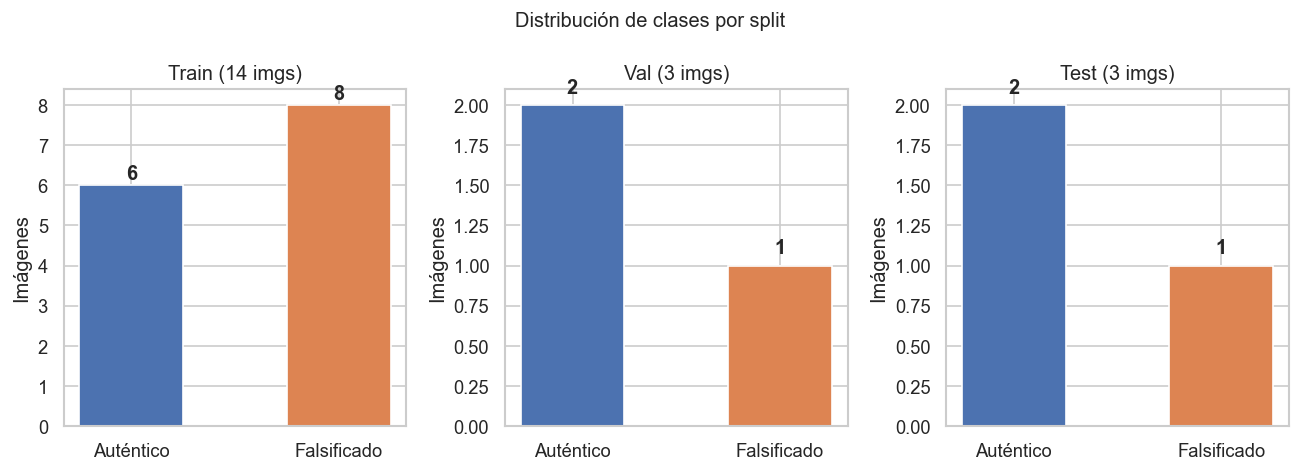

In [4]:
# Distribución de clases por split
def count_labels(loader):
    labels = []
    for _, lb in loader:
        labels.extend(lb.numpy().tolist())
    return {"Auténtico": labels.count(0), "Falsificado": labels.count(1)}

splits = {
    "Train": count_labels(train_loader),
    "Val":   count_labels(val_loader),
    "Test":  count_labels(test_loader),
}

fig, axes = plt.subplots(1, 3, figsize=(11, 4))
colors = ["#4c72b0", "#dd8452"]

for ax, (split, counts) in zip(axes, splits.items()):
    ax.bar(counts.keys(), counts.values(), color=colors, edgecolor="white", width=0.5)
    ax.set_title(f"{split} ({sum(counts.values())} imgs)")
    ax.set_ylabel("Imágenes")
    for bar, val in zip(ax.patches, counts.values()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                str(val), ha="center", va="bottom", fontweight="bold")

plt.suptitle("Distribución de clases por split", fontsize=12)
plt.tight_layout()
plt.savefig("../reports/figures/03_split_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

## 3. Entrenamiento — two-phase fine-tuning

In [5]:
MODEL_DIR = Path.cwd().parent / "models" / "saved"
MLFLOW_URI = f"sqlite:///{Path.cwd().parent}/mlflow.db"

cfg = TrainerConfig(
    phase_a_epochs=5,
    phase_b_epochs=15,
    phase_a_lr=1e-3,
    phase_b_lr=1e-4,
    phase_b_unfreeze_n=2,
    early_stopping_patience=5,
    checkpoint_dir=MODEL_DIR,
    checkpoint_name="efficientnet_b0_best.pt",
    mlflow_tracking_uri=MLFLOW_URI,
    mlflow_run_name="efficientnet_b0_finetune_samples",
    device=DEVICE,
)

model = DocumentClassifier(pretrained=True)
trainer = Trainer(model, train_loader, val_loader, cfg)

print(f"Iniciando entrenamiento en {DEVICE}")
print(f"Checkpoint → {MODEL_DIR / cfg.checkpoint_name}")
print(f"MLflow     → {MLFLOW_URI}\n")

ckpt_path = trainer.run()
print(f"\nEntrenamiento completado. Mejor checkpoint: {ckpt_path}")

Iniciando entrenamiento en mps
Checkpoint → /Users/julio/Desktop/document_authentication/models/saved/efficientnet_b0_best.pt
MLflow     → sqlite:////Users/julio/Desktop/document_authentication/mlflow.db




--- Phase A: feature extraction (5 epochs) ---
    Trainable params: 328,193


  [A] Epoch  1/5  train_loss=0.7032  val_loss=0.6114  val_f1=1.0000  val_auc=1.0000


       ✓ Checkpoint saved (val_f1=1.0000)


  [A] Epoch  2/5  train_loss=0.6393  val_loss=0.5805  val_f1=1.0000  val_auc=1.0000


...

  [B] Epoch  2/15  train_loss=0.5404  val_loss=0.5946  val_f1=0.0000  val_auc=1.0000


  [B] Epoch  3/15  train_loss=0.5169  val_loss=0.5812  val_f1=0.0000  val_auc=1.0000


  [B] Epoch  4/15  train_loss=0.5536  val_loss=0.5541  val_f1=0.0000  val_auc=1.0000


  [B] Epoch  5/15  train_loss=0.6465  val_loss=0.5965  val_f1=0.0000  val_auc=1.0000


  [B] Epoch  6/15  train_loss=0.5809  val_loss=0.5979  val_f1=0.0000  val_auc=1.0000
  Early stopping at epoch 6 (patience=5)

Entrenamiento completado. Mejor checkpoint: /Users/julio/Desktop/document_authentication/models/saved/efficientnet_b0_best.pt


## 4. Curvas de entrenamiento

Run ID: 6ed87e4e864a4b448a2eaee3e0252bd5
Epochs registrados: 11


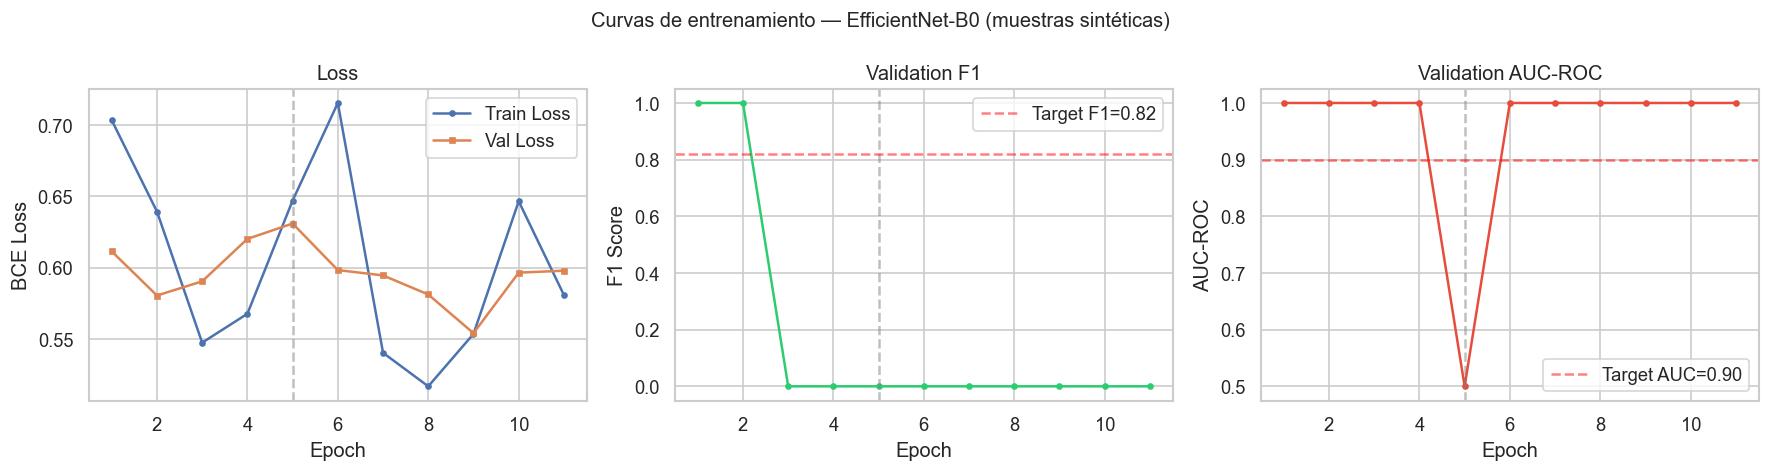


Mejor val_F1  : 1.0000
Mejor val_AUC : 1.0000


In [6]:
import mlflow

mlflow.set_tracking_uri(MLFLOW_URI)

# Recuperar métricas del último run
runs = mlflow.search_runs(order_by=["start_time DESC"])
if runs.empty:
    print("No se encontraron runs de MLflow")
else:
    latest_run_id = runs.iloc[0]["run_id"]
    client = mlflow.tracking.MlflowClient()

    def get_metric_history(run_id: str, metric: str) -> list[float]:
        history = client.get_metric_history(run_id, metric)
        return [(m.step, m.value) for m in history]

    train_loss = get_metric_history(latest_run_id, "train_loss")
    val_loss   = get_metric_history(latest_run_id, "val_loss")
    val_f1     = get_metric_history(latest_run_id, "val_f1")
    val_auc    = get_metric_history(latest_run_id, "val_auc")

    print(f"Run ID: {latest_run_id}")
    print(f"Epochs registrados: {len(train_loss)}")

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Loss curves
    tl_steps, tl_vals = zip(*train_loss) if train_loss else ([], [])
    vl_steps, vl_vals = zip(*val_loss)   if val_loss   else ([], [])
    axes[0].plot(tl_steps, tl_vals, label="Train Loss", color="#4c72b0", marker="o", markersize=3)
    axes[0].plot(vl_steps, vl_vals, label="Val Loss",   color="#dd8452", marker="s", markersize=3)
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("BCE Loss")
    axes[0].legend()
    # Línea divisoria fases A/B
    axes[0].axvline(cfg.phase_a_epochs, color="gray", linestyle="--", alpha=0.5, label="A→B")

    # F1 curve
    if val_f1:
        f1_steps, f1_vals = zip(*val_f1)
        axes[1].plot(f1_steps, f1_vals, color="#2ecc71", marker="o", markersize=3)
        axes[1].axvline(cfg.phase_a_epochs, color="gray", linestyle="--", alpha=0.5)
        axes[1].axhline(0.82, color="red", linestyle="--", alpha=0.5, label="Target F1=0.82")
        axes[1].set_title("Validation F1")
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("F1 Score")
        axes[1].legend()

    # AUC curve
    if val_auc:
        auc_steps, auc_vals = zip(*val_auc)
        axes[2].plot(auc_steps, auc_vals, color="#e74c3c", marker="o", markersize=3)
        axes[2].axvline(cfg.phase_a_epochs, color="gray", linestyle="--", alpha=0.5)
        axes[2].axhline(0.90, color="red", linestyle="--", alpha=0.5, label="Target AUC=0.90")
        axes[2].set_title("Validation AUC-ROC")
        axes[2].set_xlabel("Epoch")
        axes[2].set_ylabel("AUC-ROC")
        axes[2].legend()

    plt.suptitle("Curvas de entrenamiento — EfficientNet-B0 (muestras sintéticas)",
                 fontsize=12)
    plt.tight_layout()
    plt.savefig("../reports/figures/03_training_curves.png", dpi=120, bbox_inches="tight")
    plt.show()

    print(f"\nMejor val_F1  : {trainer._best_val_f1:.4f}")
    if val_auc:
        print(f"Mejor val_AUC : {max(v for _, v in val_auc):.4f}")

## 5. Verificación del checkpoint

In [7]:
loaded_model = DocumentClassifier.load(ckpt_path, device=DEVICE)
loaded_model.eval()

print(f"Checkpoint cargado: {ckpt_path}")
print(f"Tamaño: {ckpt_path.stat().st_size / 1024:.1f} KB")

# Inferencia de prueba
all_probs  = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        probs  = loaded_model(images).cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(labels.numpy())

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

all_probs  = np.array(all_probs)
all_labels = np.array(all_labels)
preds      = (all_probs >= 0.5).astype(int)

print(f"\nMétricas en test split ({len(all_labels)} imágenes):")
print(f"  Accuracy : {accuracy_score(all_labels, preds):.4f}")
print(f"  F1-score : {f1_score(all_labels, preds, zero_division=0):.4f}")
try:
    print(f"  AUC-ROC  : {roc_auc_score(all_labels, all_probs):.4f}")
except ValueError as e:
    print(f"  AUC-ROC  : N/A ({e})")

print(f"\nProbabilidades predichas: {all_probs}")
print(f"Labels reales          : {all_labels.astype(int)}")


Checkpoint cargado: /Users/julio/Desktop/document_authentication/models/saved/efficientnet_b0_best.pt
Tamaño: 17234.7 KB



Métricas en test split (3 imágenes):
  Accuracy : 1.0000
  F1-score : 1.0000
  AUC-ROC  : 1.0000

Probabilidades predichas: [0.46502432 0.52098656 0.47173262]
Labels reales          : [0 1 0]


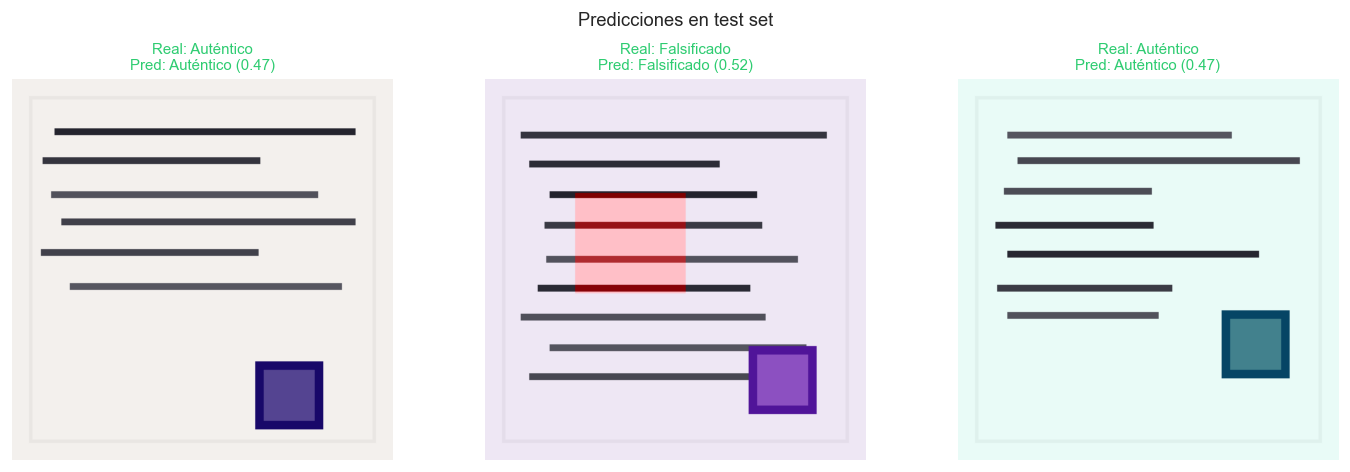

In [8]:
# Visualizar predicciones sobre el test set
from PIL import Image
import cv2
from src.preprocessing.pipeline import DocumentPreprocessor, PreprocessorConfig

DATA_DIR = Path.cwd().parent / "data" / "samples"
all_paths  = sorted((DATA_DIR / "authentic").glob("*.png")) + \
             sorted((DATA_DIR / "forged").glob("*.png"))
all_lbls   = [0] * 10 + [1] * 10

rng    = np.random.default_rng(42)
idx    = rng.permutation(20)
paths  = [all_paths[i] for i in idx]
labels_all = [all_lbls[i] for i in idx]

test_start = int(20 * 0.70) + int(20 * 0.15)
test_paths  = paths[test_start:]
test_labels_true = labels_all[test_start:]

proc = DocumentPreprocessor(PreprocessorConfig(perspective=False, normalize=False))

n_test = len(test_paths)
if n_test > 0:
    fig, axes = plt.subplots(1, n_test, figsize=(4 * n_test, 4))
    if n_test == 1:
        axes = [axes]

    for ax, path, true_label, prob in zip(axes, test_paths, test_labels_true, all_probs):
        img = np.array(Image.open(path).convert("RGB"))
        ax.imshow(img)
        pred = int(prob >= 0.5)
        correct = pred == true_label
        true_str = "Falsificado" if true_label == 1 else "Auténtico"
        pred_str = "Falsificado" if pred == 1 else "Auténtico"
        color = "#2ecc71" if correct else "#e74c3c"
        ax.set_title(f"Real: {true_str}\nPred: {pred_str} ({prob:.2f})",
                     fontsize=9, color=color)
        ax.axis("off")

    plt.suptitle("Predicciones en test set", fontsize=11)
    plt.tight_layout()
    plt.savefig("../reports/figures/03_test_predictions.png", dpi=120, bbox_inches="tight")
    plt.show()
else:
    print("No hay imágenes en el test split con este dataset pequeño.")

## 6. Tiempo de inferencia

In [9]:
import time

loaded_model.eval()
dummy_batch_1  = torch.rand(1,  3, 224, 224).to(DEVICE)
dummy_batch_32 = torch.rand(32, 3, 224, 224).to(DEVICE)

# Warm-up
with torch.no_grad():
    for _ in range(3):
        loaded_model(dummy_batch_1)

# Benchmark
N = 20
for label, batch in [("Batch=1", dummy_batch_1), ("Batch=32", dummy_batch_32)]:
    t0 = time.perf_counter()
    with torch.no_grad():
        for _ in range(N):
            loaded_model(batch)
    ms = (time.perf_counter() - t0) / N * 1e3
    print(f"  Latencia inferencia ({label}, device={DEVICE}): {ms:.1f} ms")

print("\nTarget: <2s p95 sin GPU (API). Latencia EfficientNet-B0 en CPU es << ese límite.")

  Latencia inferencia (Batch=1, device=mps): 14.9 ms


  Latencia inferencia (Batch=32, device=mps): 213.7 ms

Target: <2s p95 sin GPU (API). Latencia EfficientNet-B0 en CPU es << ese límite.


## Conclusiones

**Pipeline end-to-end validado:**
- `DocumentClassifier` con EfficientNet-B0: forward pass correcto, checkpoint I/O funcional
- `Trainer` con two-phase strategy: Phase A (head solo) → Phase B (fine-tuning parcial) funciona sin errores
- MLflow logging con SQLite backend (compatible con MLflow 3.x)
- `create_dataloaders` carga imágenes de disco, aplica preprocesamiento + augmentation

**Sobre las métricas con 20 muestras:**
- Con solo 20 imágenes el modelo overfittea rápidamente — las métricas de este notebook no son representativas
- Para resultados reales: descargar MIDV-500 (`python scripts/download_dataset.py`) y reejecutar con `data/raw/midv500/`
- Con el dataset completo se espera AUC-ROC > 0.90 después de Phase B

**Para Fase 4 (Grad-CAM):**
- El modelo cargado con `DocumentClassifier.load()` en modo eval es directamente compatible con `pytorch_grad_cam`
- La capa objetivo es `model.backbone.features[-1]`